# Intro
This notebook demonstrates how to use linear regression, a simple yet powerful machine learning (ML) technique, for making predictions. As an example, I use the Kaggle car dataset. However, the same approach can be applied to many other datasets with similar characteristics, such as Immobilien  or  2Hand Clothes. The steps remain largely consistent across these types of data.

Kaggle link: https://www.kaggle.com/datasets/CooperUnion/cardataset

The column names in this dataset are mostly self-explanatory. For reference:

- **HP**: Horsepower  
- **Highway MPG**: Highway Miles Per Gallon  
- **MSRP**: Manufacturer’s Suggested Retail Price

In [3]:
# setting up
import numpy as np
import pandas as pd

# Getting to know the data

## Loading data and fixing format

In [4]:
# I download the data from kaggle, saved it as data.csv and put it in the same folder as this notebook per drag and drop.
# There are other ways to load data from kaggle, but this is the simplest one.
df= pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


The column names in this dataset are not consistently formatted—some use underscores, while others contain spaces. To standardize them, we will convert all column names to lowercase and use underscores (`_`) as separators.

In [5]:
# accessing all the columns and applying string methods to standardize column names.
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
# Doing the same for values of text columns.
# String format in pd.DataFrame is object so we select those columns by checking the dtype.
# df.dtypes[df.dtypes == 'object'].index
# then we create a list of those columns
string_cols = list(df.dtypes[df.dtypes == 'object'].index)
string_cols

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [7]:
# Looping through each of the columns in string_cols to apply the string methods to each column.
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')
df.head()    

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## EDA

In Exploratory Data Analysis (EDA), the goal is to gain a deeper understanding of the data. It’s an iterative process that builds on the previous step.

In [8]:
# To get the first impression of the dataframe, we can use the .info() method.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  object 
 1   model              11914 non-null  object 
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  object 
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  object 
 7   driven_wheels      11914 non-null  object 
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   object 
 10  vehicle_size       11914 non-null  object 
 11  vehicle_style      11914 non-null  object 
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5

In [9]:
# But we can also go through each column and get more detailed information.
for col in df.columns:
    print(f'Column: {col}')
    print(f'Data type: {df[col].dtype}')
    print(f'Number of missing values: {df[col].isnull().sum()}')
    print(f'Unique values: {df[col].nunique()}') # number of unique values, should only be used for categorical columns actually.

# This way we can identify columns with too many missing values or columns that have more unique values than expected.
# For exploring data, it is also good to visualize it.

Column: make
Data type: object
Number of missing values: 0
Unique values: 48
Column: model
Data type: object
Number of missing values: 0
Unique values: 914
Column: year
Data type: int64
Number of missing values: 0
Unique values: 28
Column: engine_fuel_type
Data type: object
Number of missing values: 3
Unique values: 10
Column: engine_hp
Data type: float64
Number of missing values: 69
Unique values: 356
Column: engine_cylinders
Data type: float64
Number of missing values: 30
Unique values: 9
Column: transmission_type
Data type: object
Number of missing values: 0
Unique values: 5
Column: driven_wheels
Data type: object
Number of missing values: 0
Unique values: 4
Column: number_of_doors
Data type: float64
Number of missing values: 6
Unique values: 3
Column: market_category
Data type: object
Number of missing values: 3742
Unique values: 71
Column: vehicle_size
Data type: object
Number of missing values: 0
Unique values: 3
Column: vehicle_style
Data type: object
Number of missing values: 0

### Data distribution

In [ ]:
# importing matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline # this line makes sure that the plots are displayed within the notebook properly

<Axes: xlabel='msrp', ylabel='Count'>

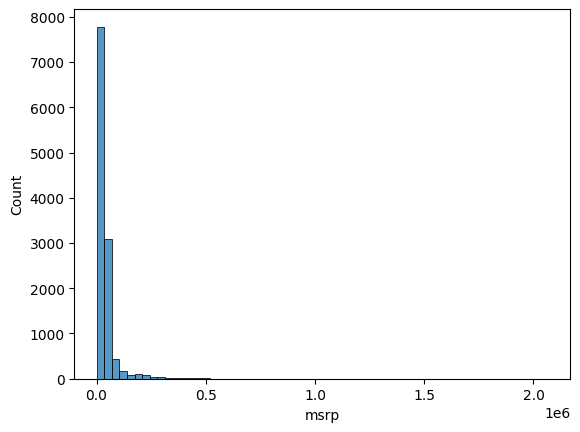

In [ ]:
# To check the distribution of numerical columns, we can use histograms.
sns.histplot(data = df.msrp, bins=60)
#1e6 means 10^6 = 1,000,000. Which means we are seeing car counts in millions.

Most cars fall into the lower price range, with a long tail extending toward higher prices.
I want to investigate whether that tail consists of true outliers or just naturally high-priced cars.
Since the goal of this analysis is to predict price, potential outliers might carry valuable information.
I also need to consider the impact of keeping these outliers in the training data. How will they influence the model’s performance and generalization? This long tail in the price distribution can cause issues for a machine learning model, as the extreme values may distort the learning process. However, we still want to provide accurate price predictions for luxury cars, so excluding them entirely is not ideal.

Proposed approach:
Train two separate models: 
   1) A model for the main dataset (with high-priced cars excluded)
   2) A dedicated model for high-end, luxury cars

Business fit:
In a real marketplace scenario, sellers can be asked to indicate whether the car is a high-end luxury vehicle.
Based on that input, the system could route the listing to the appropriate model for price prediction.
This allows more accurate pricing for both regular cars and luxury cars, instead of forcing one model to handle very different value ranges.


<Axes: xlabel='msrp', ylabel='Count'>

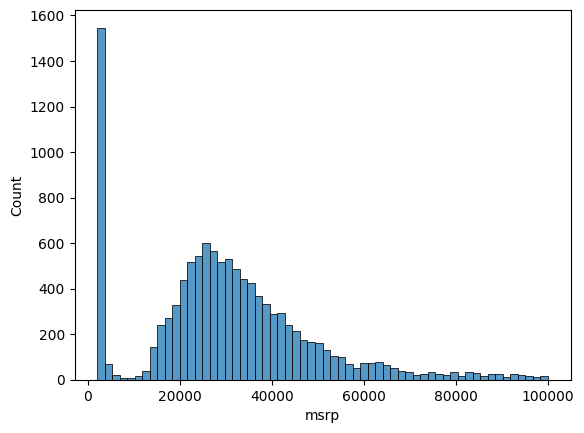

In [ ]:
sns.histplot(data = df.msrp[df.msrp < 100000], bins=60) 

The first bar appears to have the highest count, yet there are no values between 0 and that first bin.
This suggests there might be a minimum price or a hard lower limit set on the website.
The rest of the histogram looks closer to a roughly normal distribution, aside from that lower-bound constraint.


For many business cases, dividing the dataset into multiple datasets is not the optimal solution. In those cases, I apply a trick to downplay the long-tailed data, making the data more compatible with the model. Here, I will apply a log-logistic distribution to the data. This way, large values shrink more than small values. For example, a €200,000 car and a €20,000 car might be ten times apart in raw numbers, but after a log transformation, the difference becomes much smaller. This pulls the long tail closer to the rest of the distribution, often resulting in a distribution that is closer to normal (bell-shaped), which many machine learning (ML) algorithms handle better. The trade-off is that the predictions will be in log space, so I’ll need to transform them back using an exponential to show the real price.

Note: The np.log() function cannot handle zeros, so a common workaround is to add 1 to all values before applying the log transform (using np.log1p). In this dataset, car prices cannot be zero, so this adjustment is not necessary.


<Axes: xlabel='msrp', ylabel='Count'>

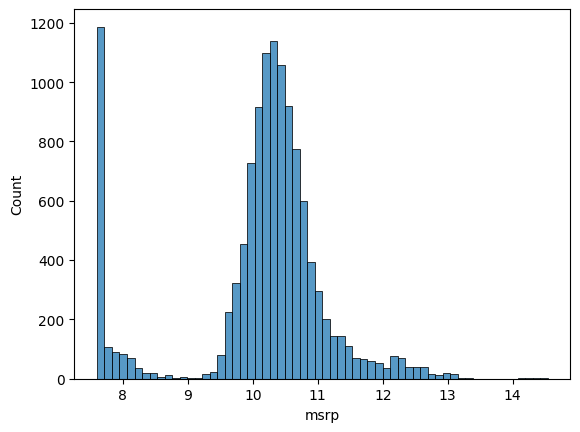

In [22]:
# Applying log transformation to the msrp column
msrp_log = np.log(df.msrp)

# Visualizing the log-transformed msrp
sns.histplot(data = msrp_log, bins=60)

### Dealing with missing values

In [23]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In this case, we could retrieve missing values for engine fuel type and engine horsepower by looking up information from the same car model. The 'market_category' feature is more challenging due to nearly 4,000 missing entries. If this feature proves to be relevant for the model, we may need to apply a more sophisticated imputation strategy to estimate it.


# Preparing Data for Training and Validation

Before splitting the data into training and test sets, it is important to shuffle it to avoid any ordering effects. If the data is sorted (e.g., by price, model year, or date), not shuffling could lead to biased splits and poor model generalization.


In [27]:
# Best practice is to split the data into training, validation, and test sets: using sklearn :-))
from sklearn.model_selection import train_test_split
# adding shuffle=True to make sure data is shuffled before splitting. random_state is set to a fixed number to make the splits reproducible.

# First split: Train (60%) vs Validation (40%)
df_train, rest = train_test_split(df, test_size=0.40, random_state=42, shuffle=True)

# Second split: Validation (20% of df aka 50% of rest) vs Test (20% of df aka 50% of rest)
df_val, df_test = train_test_split(rest, test_size=0.50, random_state=42, shuffle=True)


In [28]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
4949,nissan,frontier,2015,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,compact,crew_cab_pickup,21,15,2009,32560
579,fiat,500l,2016,premium_unleaded_(recommended),160.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,wagon,33,25,819,19495
8364,ford,ranger,2011,regular_unleaded,207.0,6.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,21,16,5657,22425
8775,chevrolet,s-10,2003,flex-fuel_(unleaded/e85),120.0,4.0,manual,rear_wheel_drive,3.0,flex_fuel,compact,extended_cab_pickup,25,19,1385,18905
7370,mitsubishi,outlander_sport,2016,regular_unleaded,168.0,4.0,automatic,four_wheel_drive,4.0,crossover,compact,4dr_suv,27,22,436,27395


In [29]:
# Cheking the sizes of the splits
print(f'Training set size: {len(df_train)}')
print(f'Validation set size: {len(df_val)}')
print(f'Test set size: {len(df_test)}')

Training set size: 7148
Validation set size: 2383
Test set size: 2383


In [ ]:
# Keeping the dataframes neat and tidy for future use
# df_train.reset_index(drop=True, inplace=True)--> dont do this, inplace=True messes up the dataframe in some cases.
# do this instead:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,nissan,frontier,2015,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,compact,crew_cab_pickup,21,15,2009,32560
1,fiat,500l,2016,premium_unleaded_(recommended),160.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,wagon,33,25,819,19495
2,ford,ranger,2011,regular_unleaded,207.0,6.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,21,16,5657,22425
3,chevrolet,s-10,2003,flex-fuel_(unleaded/e85),120.0,4.0,manual,rear_wheel_drive,3.0,flex_fuel,compact,extended_cab_pickup,25,19,1385,18905
4,mitsubishi,outlander_sport,2016,regular_unleaded,168.0,4.0,automatic,four_wheel_drive,4.0,crossover,compact,4dr_suv,27,22,436,27395


Creating y. There are two ways to create y: using pandas Series or NumPy array. To research later: when to use which method?

In [32]:
y_train = np.log(df_train.msrp.values)
y_val = np.log(df_val.msrp.values)
y_test = np.log(df_test.msrp.values)
# Output: 3 NumPy arrays of log-transformed msrp values for training, validation, and test sets without indexes.

In [ ]:
# Deleting msrp column from the dataframes as we have already created the target variable y.
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']


KeyError: 'msrp'

In [35]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,nissan,frontier,2015,regular_unleaded,261.0,6.0,automatic,four_wheel_drive,4.0,NaN,compact,crew_cab_pickup,21,15,2009
1,fiat,500l,2016,premium_unleaded_(recommended),160.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,wagon,33,25,819
2,ford,ranger,2011,regular_unleaded,207.0,6.0,manual,rear_wheel_drive,2.0,NaN,compact,extended_cab_pickup,21,16,5657
3,chevrolet,s-10,2003,flex-fuel_(unleaded/e85),120.0,4.0,manual,rear_wheel_drive,3.0,flex_fuel,compact,extended_cab_pickup,25,19,1385
4,mitsubishi,outlander_sport,2016,regular_unleaded,168.0,4.0,automatic,four_wheel_drive,4.0,crossover,compact,4dr_suv,27,22,436
